# Chronic Kidney Disease - Exploratory Data Analysis

Dataset: Chronic Kidney Disease (Kaggle - mansoordaku/ckdisease)

Goal: Understand the data before modeling. This dataset is messier than heart/diabetes - it has a mix of numeric and categorical (yes/no, normal/abnormal) columns, and real missing values, so cleaning needs more care.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/kidney_disease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [2]:
print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
df.info()

Shape: (400, 26)

Column names: ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13 

## Clean Column Names and Strip Whitespace

This dataset is known to have extra whitespace and inconsistent text values (e.g. 'yes', ' yes', 'yes ') in categorical columns - these need to be standardized first.

In [3]:
df.columns = df.columns.str.strip()

# Strip whitespace from all string/object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,nan,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,nan,normal,notpresent,notpresent,...,38,6000,nan,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,nan,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
# Check missing values (may appear as NaN or as '?' depending on how the CSV was exported)
df = df.replace('?', np.nan)
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

pot     88
sod     87
hemo    52
su      49
sg      47
al      46
bgr     44
bu      19
sc      17
bp      12
age      9
pcv      1
wc       1
rc       1
dtype: int64


## Separate Numeric vs Categorical Columns

In [5]:
# Columns like 'pcv', 'wc', 'rc' are sometimes stored as text due to messy entries - convert to numeric
for col in ['pcv', 'wc', 'rc']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
if 'id' in num_cols:
    num_cols.remove('id')

print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)

Numeric columns: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
Categorical columns: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [6]:
df[num_cols].describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


## Target Variable Distribution

The target column is usually called 'classification' with values 'ckd' / 'notckd'.

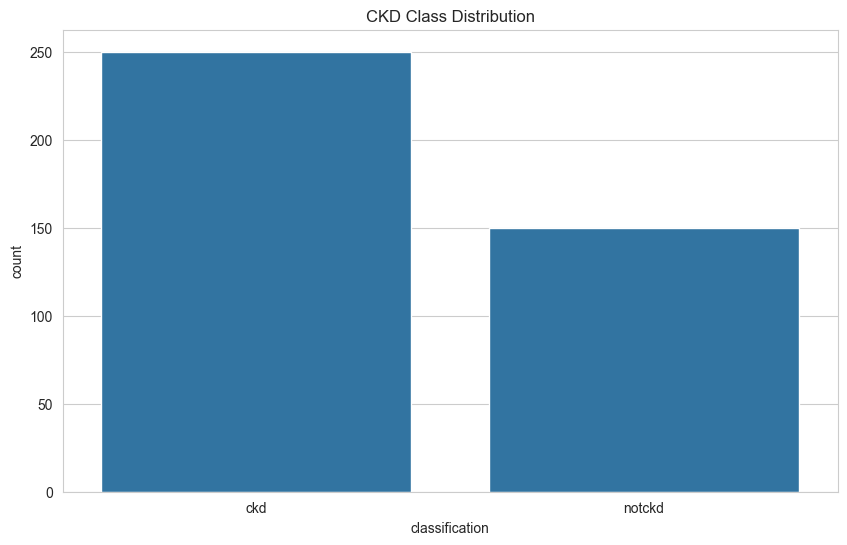

classification
ckd       0.625
notckd    0.375
Name: proportion, dtype: float64


In [7]:
target_col = 'classification' if 'classification' in df.columns else df.columns[-1]
df[target_col] = df[target_col].str.strip()

sns.countplot(x=target_col, data=df)
plt.title('CKD Class Distribution')
plt.show()

print(df[target_col].value_counts(normalize=True))

## Numerical Feature Distributions

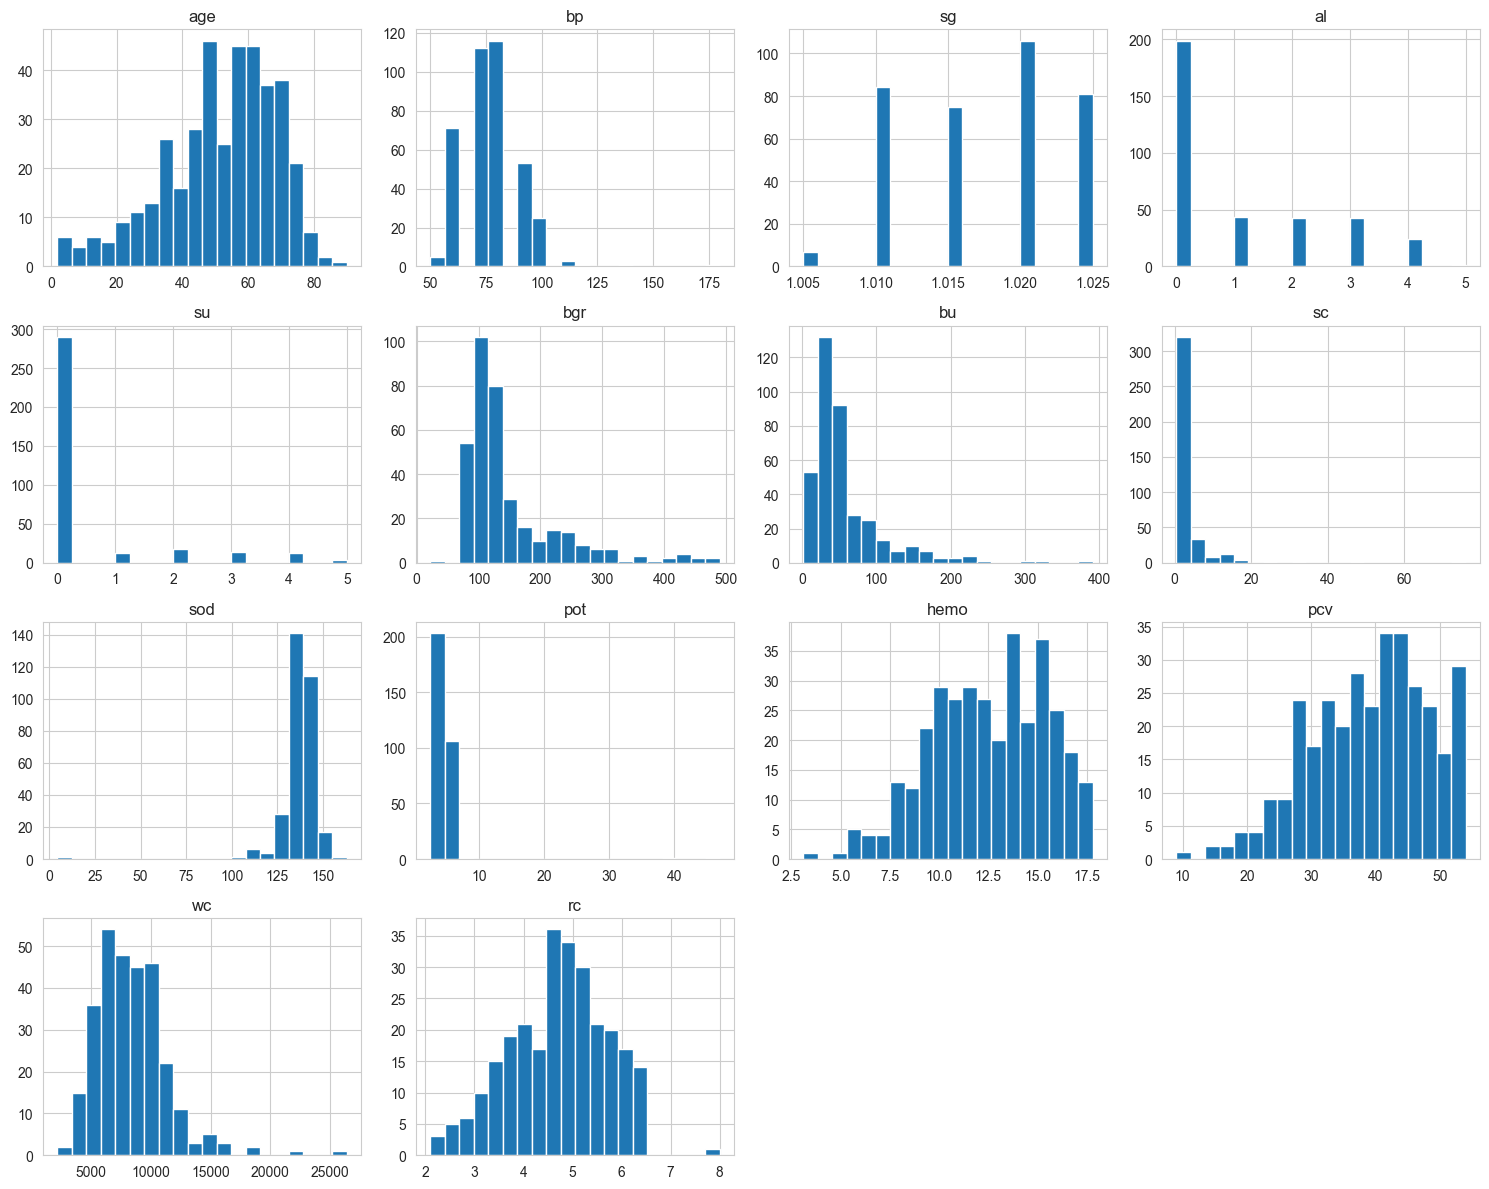

In [8]:
df[num_cols].hist(bins=20, figsize=(15, 12))
plt.tight_layout()
plt.show()

## Correlation Heatmap (numeric features only)

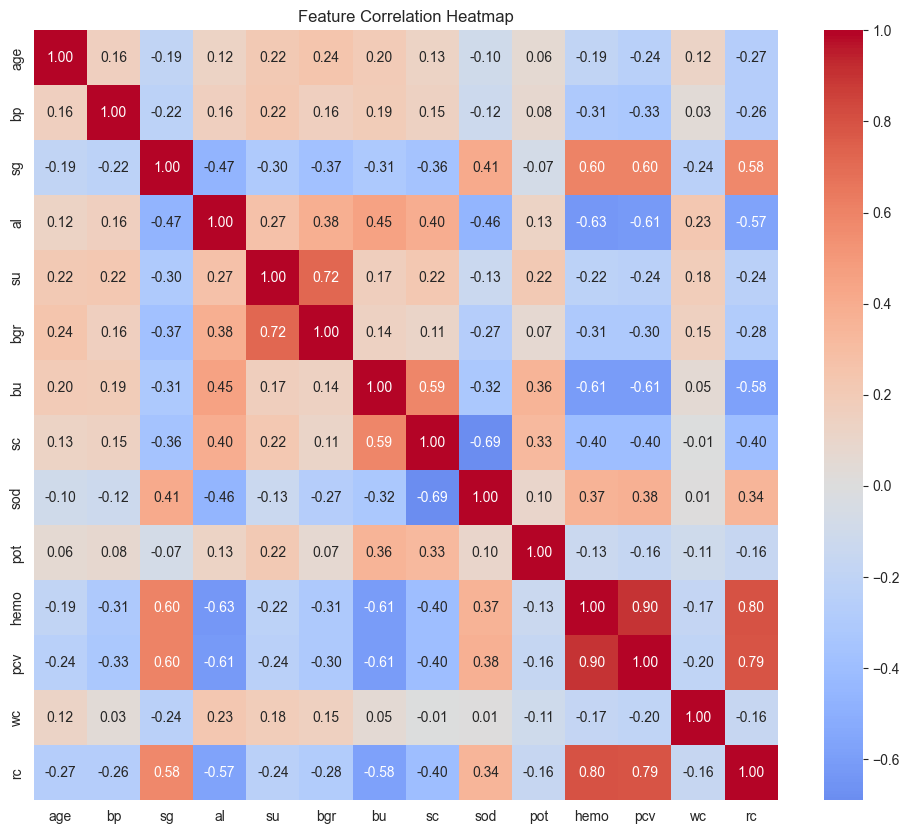

In [9]:
plt.figure(figsize=(12, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

## Categorical Feature Value Counts

In [10]:
for col in cat_cols:
    if col != target_col:
        print(f'--- {col} ---')
        print(df[col].value_counts())
        print()

--- rbc ---
rbc
normal      201
nan         152
abnormal     47
Name: count, dtype: int64

--- pc ---
pc
normal      259
abnormal     76
nan          65
Name: count, dtype: int64

--- pcc ---
pcc
notpresent    354
present        42
nan             4
Name: count, dtype: int64

--- ba ---
ba
notpresent    374
present        22
nan             4
Name: count, dtype: int64

--- htn ---
htn
no     251
yes    147
nan      2
Name: count, dtype: int64

--- dm ---
dm
no     261
yes    137
nan      2
Name: count, dtype: int64

--- cad ---
cad
no     364
yes     34
nan      2
Name: count, dtype: int64

--- appet ---
appet
good    317
poor     82
nan       1
Name: count, dtype: int64

--- pe ---
pe
no     323
yes     76
nan      1
Name: count, dtype: int64

--- ane ---
ane
no     339
yes     60
nan      1
Name: count, dtype: int64



## Key Takeaways (fill in after running)

- Columns with most missing data: ...
- Class balance (ckd vs notckd): ...
- Numeric features most correlated with CKD: ...
- Categorical features that look most informative: ...
- Cleaning needed: strip whitespace, convert pcv/wc/rc to numeric, impute missing values, encode yes/no columns